# Title :

---

## Introduction

lorem ipsum

## Methodology

lorem ipsum

### Preprocessing

In [1]:
# Import Library
!pip install xarray
!pip install geopandas
!pip install matplotlib
!pip install netCDF4
!pip install rioxarray
!pip install rasterio


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import xarray as xr
import rioxarray
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio import features

In [20]:
# Open dataset
df = xr.open_dataset("temp_data_SRS.nc", engine="netcdf4") # lazy loading, tmp files
usa = gpd.read_file("cb_2018_us_state_500k.zip").to_crs(epsg=4326) # uk boundaries shp
usa = usa[~usa["STUSPS"].isin(["AK", "HI", "PR", "AS", "VI", "GU", "MP"])] # remove non us states/territories
usa = usa.dissolve() # dissolve to single polygon

minx, miny, maxx, maxy = usa.total_bounds
print("Lon:", minx, maxx, "Lat:", miny, maxy)
geom = usa.geometry.iloc[0]

pad = 0.1 # add some padding around the polygon to make sure we get all of it (and a bit of sea around)
minx1, maxx1 = minx - pad, maxx + pad
miny1, maxy1 = miny - pad, maxy + pad

df_usa = df.sel(lon=slice(minx1, maxx1), lat=slice(miny1, maxy1))
print(df_usa)

Lon: -124.763068 -66.949895 Lat: 24.523096 49.384358
<xarray.Dataset> Size: 62MB
Dimensions:  (time: 1344, lat: 50, lon: 116)
Coordinates:
  * time     (time) datetime64[ns] 11kB 1901-01-16 1901-02-15 ... 2012-12-16
  * lat      (lat) float64 400B 24.75 25.25 25.75 26.25 ... 48.25 48.75 49.25
  * lon      (lon) float64 928B -124.8 -124.2 -123.8 ... -68.25 -67.75 -67.25
Data variables:
    tmp      (time, lat, lon) float64 62MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS3.21 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 1307101324\nData generated by BADC from:\ntmp.1307...
    history:      Wed 10 Jul 2013 17:04:15 BST : User ianharris : Program mak...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Data restrictions: for academic research use only.Contact B...
    contact:      BADC <badc@rl.ac.uk>


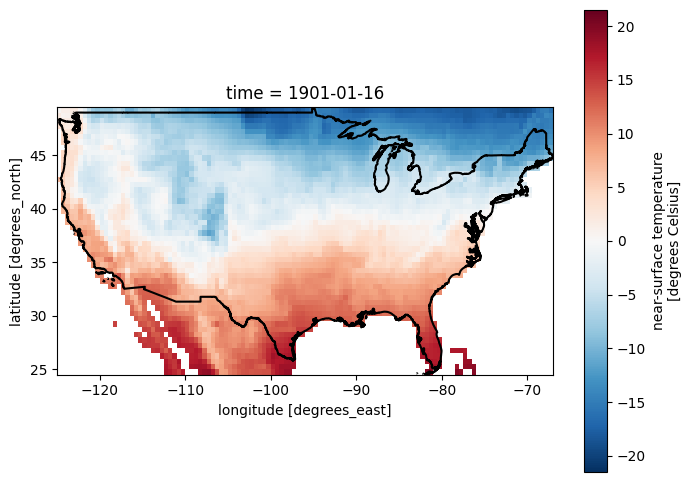

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

df_usa.tmp.isel(time=0).plot(ax=ax)

usa.boundary.plot(ax=ax, color="black")

plt.show()

In [18]:
transform = df_usa.rio.transform()
out_shape = (len(df_usa.lat), len(df_usa.lon))


In [22]:
df_usa = df_usa.sortby("lat")  # ensure lat ascending

df_usa = df_usa.rio.set_spatial_dims(
    x_dim="lon",
    y_dim="lat",
    inplace=False
)

# Ensure CRS
df_usa = df_usa.rio.write_crs("EPSG:4326")
print(df_usa)
# Clip using polygon with intersection logic
df_usa = df_usa.rio.clip(
    usa.geometry,
    usa.crs,
    all_touched=True,   # 🔥 critical
    drop=True
)

<xarray.Dataset> Size: 62MB
Dimensions:      (time: 1344, lat: 50, lon: 116)
Coordinates:
  * time         (time) datetime64[ns] 11kB 1901-01-16 1901-02-15 ... 2012-12-16
  * lat          (lat) float64 400B 24.75 25.25 25.75 ... 48.25 48.75 49.25
  * lon          (lon) float64 928B -124.8 -124.2 -123.8 ... -67.75 -67.25
    spatial_ref  int64 8B 0
Data variables:
    tmp          (time, lat, lon) float64 62MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS3.21 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 1307101324\nData generated by BADC from:\ntmp.1307...
    history:      Wed 10 Jul 2013 17:04:15 BST : User ianharris : Program mak...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Data restrictions: for academic research use only.Contact B...
    contact:      BADC <badc@rl.ac.uk>


<Axes: title={'center': 'time = 1984-05-16, spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

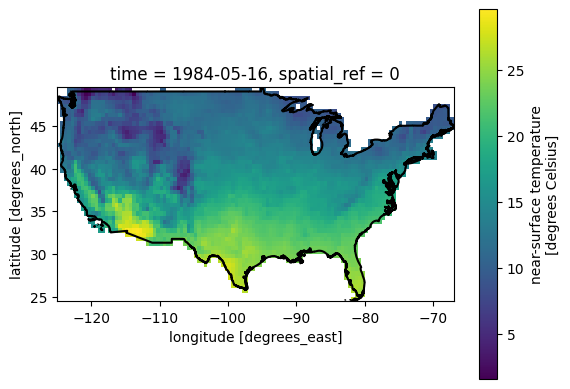

In [23]:
df_usa.tmp.isel(time=1000).plot()
usa.boundary.plot(ax=plt.gca(), color="black")

In [24]:
df_usa.to_netcdf(
    "us_temp.nc",
    format="NETCDF4"
)